In [1]:
import zipfile
import os

# Extract the zip file
with zipfile.ZipFile('archive (4).zip', 'r') as zip_ref:
    zip_ref.extractall('.')

print("✅ Done! Files:")
for f in os.listdir('.'):
    print(f)

✅ Done! Files:
.config
googleplaystore_user_reviews.csv
license.txt
googleplaystore.csv
archive (4).zip
sample_data


In [2]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv('googleplaystore.csv')

# Drop duplicates
df.drop_duplicates(inplace=True)

# Clean Installs → numeric
df['Installs'] = df['Installs'].str.replace('[+,]', '', regex=True)
df['Installs'] = pd.to_numeric(df['Installs'], errors='coerce')

# Clean Rating → numeric
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')

# Clean Reviews → numeric
df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')

# Clean Size → MB
def convert_size(size):
    if 'M' in str(size):
        return float(str(size).replace('M', ''))
    elif 'k' in str(size):
        return float(str(size).replace('k', '')) / 1024
    else:
        return None

df['Size_MB'] = df['Size'].apply(convert_size)

# Clean Last Updated → datetime
df

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_MB
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159.0,19M,10000.0,Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up,19.0
1,Coloring book moana,ART_AND_DESIGN,3.9,967.0,14M,500000.0,Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,14.0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510.0,8.7M,5000000.0,Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up,8.7
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644.0,25M,50000000.0,Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up,25.0
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967.0,2.8M,100000.0,Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up,2.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10836,Sya9a Maroc - FR,FAMILY,4.5,38.0,53M,5000.0,Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up,53.0
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4.0,3.6M,100.0,Free,0,Everyone,Education,"July 6, 2018",1.0,4.1 and up,3.6
10838,Parkinson Exercices FR,MEDICAL,NaN,3.0,9.5M,1000.0,Free,0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up,9.5
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114.0,Varies with device,1000.0,Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device,NaN


In [4]:
# Filter 1: Rating >= 4.2
df = df[df['Rating'] >= 4.2]

# Filter 2: App name should NOT contain numbers
df = df[~df['App'].str.contains(r'\d', regex=True)]

# Filter 3: Category starts with T or P
df = df[df['Category'].str.startswith(('T', 'P'))]

# Filter 4: Reviews > 1000
df = df[df['Reviews'] > 1000]

# Filter 5: App size between 20MB and 80MB
df = df[(df['Size_MB'] >= 20) & (df['Size_MB'] <= 80)]

# Translate category names
translation_map = {
    'TRAVEL_AND_LOCAL': 'Voyage & Local (Travel)',
    'PRODUCTIVITY': 'Productividad (Productivity)',
    'PHOTOGRAPHY': 'Shashin - Photography'
}
df['Category'] = df['Category'].replace(translation_map)

print("Filters applied! Shape:", df.shape)
print("Categories:", df['Category'].unique())

Filters applied! Shape: (129, 14)
Categories: ['Shashin - Photography' 'Voyage & Local (Travel)' 'TOOLS'
 'PERSONALIZATION' 'Productividad (Productivity)' 'PARENTING']


In [6]:
# Fix Last Updated column to datetime
df['Last Updated'] = pd.to_datetime(df['Last Updated'], errors='coerce')
df.dropna(subset=['Last Updated'], inplace=True)

# Create Year-Month column
df['YearMonth'] = df['Last Updated'].dt.to_period('M')

# Group by YearMonth and Category → cumulative installs
time_series = df.groupby(['YearMonth', 'Category'])['Installs'].sum().reset_index()
time_series['YearMonth'] = time_series['YearMonth'].dt.to_timestamp()
time_series = time_series.sort_values(['Category', 'YearMonth'])

# Calculate cumulative installs per category
time_series['Cumulative_Installs'] = time_series.groupby('Category')['Installs'].cumsum()

# Calculate MoM growth
time_series['MoM_Growth'] = time_series.groupby('Category')['Cumulative_Installs'].pct_change() * 100

print("✅ Time series ready!")
print(time_series.head(10))

✅ Time series ready!
    YearMonth         Category    Installs  Cumulative_Installs    MoM_Growth
16 2018-03-01        PARENTING    100000.0             100000.0           NaN
19 2018-05-01        PARENTING  10000000.0           10100000.0  10000.000000
26 2018-07-01        PARENTING    600000.0           10700000.0      5.940594
2  2016-12-01  PERSONALIZATION   2000000.0            2000000.0           NaN
7  2017-09-01  PERSONALIZATION   1000000.0            3000000.0     50.000000
11 2018-01-01  PERSONALIZATION  10000000.0           13000000.0    333.333333
14 2018-02-01  PERSONALIZATION  10000000.0           23000000.0     76.923077
22 2018-06-01  PERSONALIZATION  10000000.0           33000000.0     43.478261
27 2018-07-01  PERSONALIZATION  11500000.0           44500000.0     34.848485
32 2018-08-01  PERSONALIZATION  20000000.0           64500000.0     44.943820


Current IST hour: 16


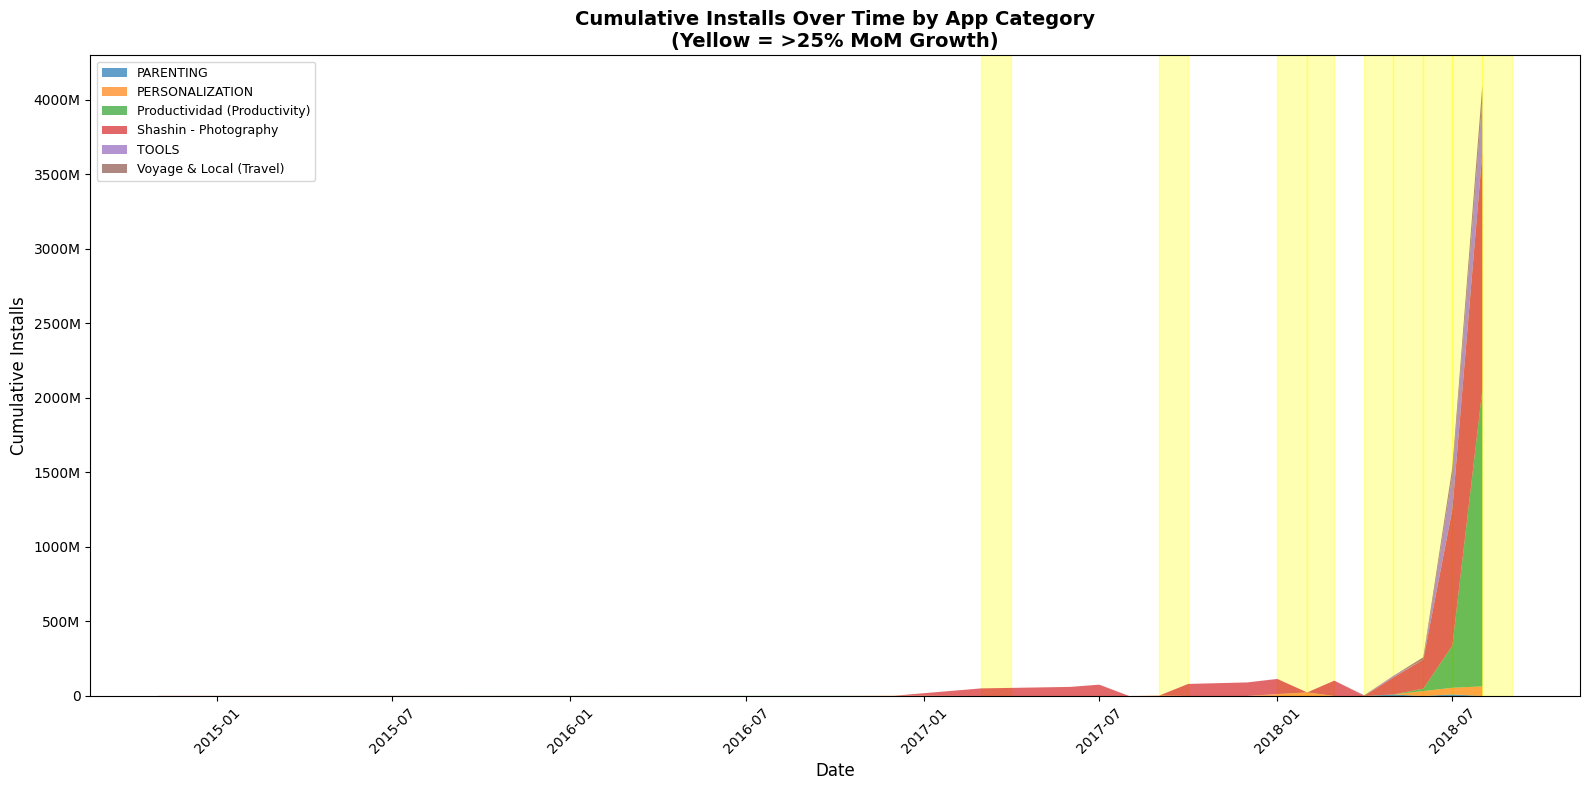

✅ Chart saved as task6_stacked_area.png


In [7]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from datetime import datetime
import pytz

# Check current IST time
ist = pytz.timezone('Asia/Kolkata')
current_hour = datetime.now(ist).hour

print(f"Current IST hour: {current_hour}")

if not (16 <= current_hour < 18):
    print("⛔ Chart is only available between 4 PM and 6 PM IST. Please come back then.")

else:
    # Pivot for stacked area chart
    pivot_df = time_series.pivot_table(
        index='YearMonth',
        columns='Category',
        values='Cumulative_Installs',
        fill_value=0
    )

    fig, ax = plt.subplots(figsize=(16, 8))
    categories = pivot_df.columns.tolist()
    colors = plt.cm.tab10.colors

    # Plot stacked area
    ax.stackplot(pivot_df.index,
                 [pivot_df[cat] for cat in categories],
                 labels=categories,
                 colors=colors[:len(categories)],
                 alpha=0.7)

    # Highlight months where any category MoM growth > 25%
    highlight_months = time_series[time_series['MoM_Growth'] > 25]['YearMonth'].unique()
    for month in highlight_months:
        ax.axvspan(month, month + pd.DateOffset(months=1),
                   alpha=0.3, color='yellow', zorder=0)

    ax.set_title('Cumulative Installs Over Time by App Category\n(Yellow = >25% MoM Growth)',
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Cumulative Installs', fontsize=12)
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda val, _: f'{val/1e6:.0f}M' if val >= 1e6 else f'{int(val):,}')
    )
    ax.legend(loc='upper left', fontsize=9)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('task6_stacked_area.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Chart saved as task6_stacked_area.png")